<a href="https://colab.research.google.com/github/ericleerepo/Puma_Project/blob/main/LLM_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
  import os, re, glob, math, warnings
from typing import List, Tuple, Dict
import numpy as np
import pandas as pd
from collections import Counter

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt # Import matplotlib for confusion matrix display

warnings.filterwarnings("ignore", category=UserWarning)

# ----- Safe mount (no-op if already mounted) -----
if os.path.isdir("/content/drive/MyDrive"):
    print("Drive already mounted; skipping.")
else:
    drive.mount("/content/drive", force_remount=False)

# ----- Config -----
DATA_ROOT   = "/content/drive/MyDrive/Colab_Notebooks/123F Labeled Accel Data (Final)"
FS          = 16.0
WINDOW_SEC  = 10.0
OVERLAP     = 0.5
HOP_S       = WINDOW_SEC * (1.0 - OVERLAP)  # 5 s per window step
LABELS_ORDER = ["resting", "moving", "feeding"]
TARGET_LABELS = set(LABELS_ORDER)
BANDS = [(0.1,0.5),(0.5,2.0),(2.0,4.0),(4.0,6.0),(6.0,8.0)]
RNG_SEED = 42

# Baseline prior factor for feeding outside allowed times (for comparison only in this cell)
FEEDING_PRIOR_BASE = 0.01

# Transition diagonal floors (stickiness) for the 'tuned' HMM without prior
DIAG_FLOOR_ALL   = 0.80
DIAG_FLOOR_FEED  = 0.85

# Post-process: fill short non-feeding gaps inside feeding bouts (K windows)
K_GAP_FILL_FEED = 4   # 4 windows * 5 s = 20 s gaps are closed

# ----- File discovery & columns -----
AX_COL, AY_COL, AZ_COL = "Acc X [g]", "Acc Y [g]", "Acc Z [g]"
SEC_COL, LAB_COL = "Seconds", "Label"

Mounted at /content/drive


In [ ]:
import os, re, glob, math, warnings
from typing import List, Tuple, Dict
import numpy as np
import pandas as pd
from collections import Counter

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt # Import matplotlib for confusion matrix display

warnings.filterwarnings("ignore", category=UserWarning)

# ----- Safe mount (no-op if already mounted) -----
if os.path.isdir("/content/drive/MyDrive"):
    print("Drive already mounted; skipping.")
else:
    drive.mount("/content/drive", force_remount=False)

# ----- Config -----
DATA_ROOT   = "/content/drive/MyDrive/123F Labeled Accel Data (Final)"
FS          = 16.0
WINDOW_SEC  = 10.0
OVERLAP     = 0.5
HOP_S       = WINDOW_SEC * (1.0 - OVERLAP)  # 5 s per window step
LABELS_ORDER = ["resting", "moving", "feeding"]
TARGET_LABELS = set(LABELS_ORDER)
BANDS = [(0.1,0.5),(0.5,2.0),(2.0,4.0),(4.0,6.0),(6.0,8.0)]
RNG_SEED = 42

# Baseline prior factor for feeding outside allowed times (for comparison only in this cell)
FEEDING_PRIOR_BASE = 0.01

# Transition diagonal floors (stickiness) for the 'tuned' HMM without prior
DIAG_FLOOR_ALL   = 0.80
DIAG_FLOOR_FEED  = 0.85

# Post-process: fill short non-feeding gaps inside feeding bouts (K windows)
K_GAP_FILL_FEED = 4   # 4 windows * 5 s = 20 s gaps are closed

# ----- File discovery & columns -----
AX_COL, AY_COL, AZ_COL = "Acc X [g]", "Acc Y [g]", "Acc Z [g]"
SEC_COL, LAB_COL = "Seconds", "Label"

Drive already mounted; skipping.


In [ ]:
def get_transition_matrix(labels, diag_all=0.80, diag_feed=0.85):
    n = len(labels)
    trans = np.full((n, n), (1.0 - diag_all) / (n - 1))
    for i, label in enumerate(labels):
        if label == "feeding":
            trans[i, i] = diag_feed
            remaining = 1.0 - diag_feed
            for j in range(n):
                if i != j: trans[i, j] = remaining / (n - 1)
        else:
            trans[i, i] = diag_all
    return trans

def viterbi_smoothing(obs_labels, states, trans_mtx):
    state_to_idx = {s: i for i, s in enumerate(states)}
    n_obs = len(obs_labels)
    n_states = len(states)
    emit_p = 0.9

    viterbi = np.zeros((n_states, n_obs))
    path = np.zeros((n_states, n_obs), dtype=int)

    first_idx = state_to_idx.get(obs_labels[0], 0)
    for s in range(n_states):
        viterbi[s, 0] = np.log(1.0/n_states) + np.log(emit_p if s == first_idx else (1-emit_p)/(n_states-1))

    for t in range(1, n_obs):
        obs_idx = state_to_idx.get(obs_labels[t], 0)
        for s in range(n_states):
            prob_emit = np.log(emit_p if s == obs_idx else (1-emit_p)/(n_states-1))
            scores = viterbi[:, t-1] + np.log(trans_mtx[:, s]) + prob_emit
            path[s, t] = np.argmax(scores)
            viterbi[s, t] = np.max(scores)

    out_indices = [np.argmax(viterbi[:, -1])]
    for t in range(n_obs - 1, 0, -1):
        out_indices.append(path[out_indices[-1], t])

    return [states[i] for i in reversed(out_indices)]

if 'subset_data' in locals() and 'gemini_pred' in subset_data.columns:
    A = get_transition_matrix(LABELS_ORDER, DIAG_FLOOR_ALL, DIAG_FLOOR_FEED)
    smoothed_list = []
    for file_name, group in subset_data.groupby('hour_file'):
        obs = group['gemini_pred'].tolist()
        smoothed = viterbi_smoothing(obs, LABELS_ORDER, A)
        smoothed_list.extend(smoothed)

    subset_data['hmm_pred'] = smoothed_list
    print("HMM smoothing complete.")
    display(subset_data[['label', 'gemini_pred', 'hmm_pred']].head())
else:
    print("Please run the Gemini prediction cell first.")

Please run the Gemini prediction cell first.


In [ ]:
def find_all_hour_files(data_root: str):
    patt1 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.csv"), recursive=True)
    patt2 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.CSV"), recursive=True)
    return sorted(set(patt1 + patt2))

def is_hour_15(path: str) -> bool:
    base = os.path.basename(path)
    m = re.search(r"_(\d{2})_synced_labeled\.csv$", base, flags=re.IGNORECASE)
    return (m is not None) and (m.group(1) == "15")

def normalize_label_series(s: pd.Series) -> pd.Series:
    # Strip whitespace and force lowercase for consistent matching
    return s.astype(str).str.strip().str.lower()

# ----- Feature helpers (as in your pipeline) -----
def moving_average(x: np.ndarray, k: int) -> np.ndarray:
    if k <= 1 or len(x) == 0: return x.copy()
    kern = np.ones(k, dtype=float) / float(k)
    return np.convolve(x, kern, mode="same")

def compute_dynamic(ax, ay, az, fs, win_sec=2.0):
    k = max(1, int(round(win_sec * fs)))
    ax_stat = moving_average(ax, k)
    ay_stat = moving_average(ay, k)
    az_stat = moving_average(az, k)
    dx, dy, dz = ax - ax_stat, ay - ay_stat, az - az_stat
    dm = np.sqrt(dx*dx + dy*dy + dz*dz)
    return dx, dy, dz, dm

def dominant_freq_amp(sig: np.ndarray, fs: float):
    n = len(sig)
    if n < 4: return 0.0, 0.0
    x = sig - np.nanmean(sig)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    if len(freqs) <= 1: return 0.0, 0.0
    X = X.copy(); X[0] = 0.0 + 0.0j
    idx = int(np.nanargmax(np.abs(X)))
    return float(freqs[idx]), float(np.abs(X[idx]))

def bandpowers(sig: np.ndarray, fs: float, bands):
    if len(sig) < 4: return [0.0]*len(bands)
    x = sig - np.nanmean(sig)
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    X = np.fft.rfft(x)
    psd = (np.abs(X) ** 2) / max(n,1)
    out = []
    for (f1,f2) in bands:
        m = (freqs>=f1) & (freqs<f2)
        out.append(float(np.nanmean(psd[m])) if np.any(m) else 0.0)
    return out

def ac_features(sig: np.ndarray, fs: float, max_lag_s: float = 1.5):
    n = len(sig); out = {"ac_max":0.0,"ac_lag_max_s":0.0,"ac_mean_3_8":0.0,"ac_mean_9_16":0.0}
    if n < 4: return out
    x = sig - np.nanmean(sig)
    corr = np.correlate(x, x, mode="full")
    mid = len(corr)//2
    ac = corr[mid:]
    if ac[0] <= 0: return out
    ac = ac / ac[0]
    L = min(int(round(max_lag_s*fs)), len(ac)-1)
    if L < 1: return out
    ac_pos = ac[1:L+1]
    k = int(np.argmax(ac_pos))
    out["ac_max"] = float(ac_pos[k])
    out["ac_lag_max_s"] = float((k+1)/fs)
    def safe_mean(lo,hi):
        lo = max(lo,1); hi = min(hi, len(ac)-1)
        if hi < lo: return 0.0
        seg = ac[lo:hi+1]
        return float(np.nanmean(seg)) if seg.size else 0.0
    out["ac_mean_3_8"]  = safe_mean(3,8)
    out["ac_mean_9_16"] = safe_mean(9,16)
    return out

def build_feature_table(files: List[str], fs: float, window_sec: float, overlap: float):
    WINDOW = int(window_sec * fs)
    HOP = max(1, int(WINDOW * (1 - overlap)))
    rows = []

    for path in files:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print("Failed to read:", os.path.basename(path), "->", e); continue

        df[LAB_COL] = normalize_label_series(df[LAB_COL])
        # No filtering by TARGET_LABELS, include all labels
        df = df[df[LAB_COL].notna() & (df[LAB_COL] != '')].copy() # Ensure labels are not NaN or empty
        if df.empty: continue

        ax = pd.to_numeric(df[AX_COL], errors="coerce").to_numpy()
        ay = pd.to_numeric(df[AY_COL], errors="coerce").to_numpy()
        az = pd.to_numeric(df[AZ_COL], errors="coerce").to_numpy()
        sec = pd.to_numeric(df[SEC_COL], errors="coerce").to_numpy()
        lab = df[LAB_COL].to_numpy()
        n = len(df)
        if n < WINDOW: continue

        dx, dy, dz, dm = compute_dynamic(ax, ay, az, fs, win_sec=2.0)
        mag = np.sqrt(ax*ax + ay*ay + az*az)

        for start in range(0, n - WINDOW + 1, HOP):
            end = start + WINDOW
            sl = slice(start, end)
            win_labels = lab[sl]
            # Filter out NaN or empty strings from window labels before value_counts()
            valid_win_labels = [l for l in win_labels if pd.notna(l) and l != '']
            if not valid_win_labels: continue
            win_label = pd.Series(valid_win_labels).value_counts().index[0]
            # No filtering by TARGET_LABELS

            axw, ayw, azw = ax[sl], ay[sl], az[sl]
            dxw, dyw, dzw, dmw = dx[sl], dy[sl], dz[sl], dm[sl]
            magw = mag[sl]

            feats = {}
            for nm, arr in [("ax",axw),("ay",ayw),("az",azw),("mag",magw)]:
                feats[f"{nm}_mean"] = float(np.nanmean(arr))
                feats[f"{nm}_std"]  = float(np.nanstd(arr))
                feats[f"{nm}_min"]  = float(np.nanmin(arr))
                feats[f"{nm}_max"]  = float(np.nanmax(arr))
                q75, q25 = np.nanpercentile(arr, 75), np.nanpercentile(arr, 25)
                feats[f"{nm}_iqr"]  = float(q75 - q25)
                feats[f"{nm}_madiff"] = float(np.nanmean(np.abs(np.diff(arr)))) if len(arr)>1 else 0.0

            feats["ODBA_X"] = float(np.nanmean(np.abs(dxw)))
            feats["ODBA_Y"] = float(np.nanmean(np.abs(dyw)))
            feats["ODBA_Z"] = float(np.nanmean(np.abs(dzw)))
            feats["ODBA_Sum"] = feats["ODBA_X"] + feats["ODBA_Y"] + feats["ODBA_Z"]
            feats["SDX_dyn"] = float(np.nanstd(dxw))
            feats["SDY_dyn"] = float(np.nanstd(dyw))
            feats["SDZ_dyn"] = float(np.nanstd(dzw))
            feats["SDM_dyn"] = float(np.nanstd(dmw))
            for nm, arr in [("X",dxw),("Y",dyw),("Z",dzw),("M",dmw)]:
                f_dom, amp_dom = dominant_freq_amp(arr,fs)
                feats[f"DF{nm}"] = f_dom
                feats[f"Amp{nm}"] = amp_dom

            bp = bandpowers(dmw, fs, BANDS)
            for i,(f1,f2) in enumerate(BANDS):
                feats[f"dm_bp_{f1:.1f}_{f2:.1f}"] = bp[i]

            feats.update(ac_features(dmw, fs, max_lag_s=1.5))

            feats["t_start"]   = float(sec[start]) if not math.isnan(sec[start]) else float(start/FS)
            feats["t_end"]     = float(sec[end-1]) if not math.isnan(sec[end-1]) else float((end-1)/FS)
            feats["hour_file"] = os.path.basename(path)
            feats["day_key"]   = feats["hour_file"].split("_")[0]
            feats["label"]     = win_label
            rows.append(feats)
    return pd.DataFrame(rows)

In [ ]:
FILES_ALL = find_all_hour_files(DATA_ROOT)
FILES = [f for f in FILES_ALL if not is_hour_15(f)]
print(f"Found {len(FILES_ALL)} files; using {len(FILES)} (excluded hour-15).")

Found 336 files; using 322 (excluded hour-15).


In [ ]:
print("Building features…")
# Target a specific file within a subfolder
subfolder = "211207_annotated"

# Filter the global list of files to only include those within the specified subfolder
files_in_subfolder = [f for f in FILES if subfolder in f]

if files_in_subfolder:
    print(f"Processing {len(files_in_subfolder)} files in subfolder: {subfolder}")
    data = build_feature_table(files_in_subfolder, FS, WINDOW_SEC, OVERLAP)
else:
    print(f"Error: No files found in subfolder: {subfolder}")
    data = pd.DataFrame() # Initialize an empty DataFrame if no files are found

if 'data' in locals() and not data.empty:
    print(f"Feature table: {data.shape}")
    print("Label counts:\n", data["label"].value_counts())
    display(data.head())
else:
    print("No data to display.")

Building features…
Processing 23 files in subfolder: 211207_annotated
Feature table: (16551, 54)
Label counts:
 label
resting      12822
moving        1307
feeding        998
uncertain      747
nan            657
drinking        20
Name: count, dtype: int64


,ax_mean,ax_std,ax_min,ax_max,ax_iqr,ax_madiff,ay_mean,ay_std,ay_min,ay_max,...,dm_bp_6.0_8.0,ac_max,ac_lag_max_s,ac_mean_3_8,ac_mean_9_16,t_start,t_end,hour_file,day_key,label
0,1.124312,0.019125,1.06,1.13,0.00,0.008805,0.066312,0.091656,-0.06,0.25,...,0.000663,0.896469,0.0625,0.521897,0.147239,0.2783,7.2783,211207_00_synced_labeled.csv,211207,resting
1,1.105938,0.033247,1.06,1.13,0.07,0.028616,0.185312,0.090180,0.00,0.25,...,0.000124,0.740324,0.0625,0.515354,0.319768,3.2783,12.2783,211207_00_synced_labeled.csv,211207,resting
2,1.081000,0.032078,1.06,1.13,0.07,0.027296,0.250000,0.000000,0.25,0.25,...,0.000077,0.527343,0.0625,0.411617,0.327751,8.2783,17.2783,211207_00_synced_labeled.csv,211207,resting
3,1.074438,0.028323,1.06,1.13,0.00,0.009245,0.231000,0.051359,0.06,0.25,...,0.000122,0.585147,0.0625,0.381937,0.238702,13.2783,22.2783,211207_00_synced_labeled.csv,211207,resting
4,1.104625,0.033651,1.06,1.13,0.07,0.002201,0.120625,0.105242,0.00,0.25,...,0.000086,0.744488,0.0625,0.566739,0.277098,18.2783,27.2783,211207_00_synced_labeled.csv,211207,resting


In [ ]:
!pip install -q google-genai

In [ ]:
from google.colab import userdata
from google import genai

client = genai.Client(api_key=userdata.get("Gemini_API"))

In [ ]:
import json
import asyncio
import random
import time
import re
from typing import Any, Optional, Dict, List, Tuple

MODEL = "gemini-3-flash-preview"
EXCLUDE = {"t_start", "t_end", "hour_file", "day_key", "label"}

FEATURE_DEFINITIONS = """
Feature definitions:
- ax/ay/az: raw accelerometer axes
- mag: vector magnitude
- ODBA_Sum: Overall Dynamic Body Acceleration (intensity)
- SDX/Y/Z/M_dyn: std of dynamic acceleration
- DFX/Y/Z/M: dominant frequency
- dm_bp_*: bandpower in frequency bands
- ac_*: autocorrelation (periodicity/regularity)
"""

def format_features(row: Any) -> Dict[str, float]:
    """Extract and round numeric features from a Series or Dict."""
    out: Dict[str, float] = {}
    # Handle both Series and dict-like objects
    items = row.items() if hasattr(row, 'items') else row._asdict().items()
    for k, v in items:
        if k in EXCLUDE:
            continue
        try:
            out[k] = round(float(v), 4)
        except (ValueError, TypeError):
            continue
    return out

def make_prompt_with_context(
    row: Any,
    allowed_labels: List[str],
    preceding_rows: List[Any] = None,
    preceding_preds: List[str] = None
) -> str:
    """Constructs the final text prompt with historical context."""
    allowed = [str(x).strip().lower() for x in allowed_labels]

    context_str = ""
    if preceding_rows:
        for i, p_row in enumerate(preceding_rows):
            p_feats = format_features(p_row)
            context_str += f"Window T-{len(preceding_rows)-i}: {json.dumps(p_feats, separators=(',', ':'))}\n"
    else:
        context_str = "None (Start of sequence)"

    current_feats = format_features(row)

    return (
        "You are classifying a window of puma collar accelerometer data.\n"
        f"Allowed labels: {allowed}\n"
        f"{FEATURE_DEFINITIONS}\n"
        "### HISTORICAL CONTEXT (PRECEDING WINDOWS):\n"
        f"{context_str}\n"
        "### CURRENT WINDOW (CLASSIFY THIS):\n"
        f"{json.dumps(current_feats, separators=(',', ':'))}\n"
        "Return ONLY valid JSON: {\"label\": \"<one allowed label>\"}"
    )

def make_prompt_with_feature_context(
    idx: int,
    df: "pd.DataFrame",
    allowed_labels: List[str],
    n_context: int = 2,
) -> str:
    """Selects the current row and preceding rows to build a context-aware prompt."""
    row = df.iloc[idx]
    # Get preceding rows, ensuring they belong to the same hour_file to avoid cross-day context
    current_file = row['hour_file']
    start_idx = max(0, idx - n_context)
    preceding_rows = []
    for k in range(start_idx, idx):
        p_row = df.iloc[k]
        if p_row['hour_file'] == current_file:
            preceding_rows.append(p_row)

    return make_prompt_with_context(row, allowed_labels, preceding_rows, preceding_preds=None)

def _strip_code_fences(text: str) -> str:
    t = text.strip()
    if t.startswith("```"):
        t = re.sub(r"^```[a-zA-Z0-9]*\s*", "", t)
        t = re.sub(r"\s*```$", "", t)
    return t.strip()

def parse_label_from_json(text: str, allowed_labels_set: set) -> Optional[str]:
    if not text: return None
    t = _strip_code_fences(text)
    try:
        obj = json.loads(t)
        lab = str(obj.get("label", "")).strip().lower()
        return lab if lab in allowed_labels_set else None
    except: pass
    m = re.search(r"\{.*?\}", t, flags=re.DOTALL)
    if m:
        try:
            obj = json.loads(m.group(0))
            lab = str(obj.get("label", "")).strip().lower()
            return lab if lab in allowed_labels_set else None
        except: pass
    return None

async def classify_all_worker_pool(
    client,
    df: "pd.DataFrame",
    allowed_labels: List[str],
    *,
    max_concurrent: int = 30,
    max_retries: int = 3,
    timeout_s: float = 60.0,
) -> List[str]:
    allowed_set = set([str(x).strip().lower() for x in allowed_labels])
    n = len(df)
    preds = ["unknown"] * n
    q = asyncio.Queue()
    for i in range(n): q.put_nowait(i)

    async def worker():
        while not q.empty():
            idx = await q.get()
            prompt = make_prompt_with_feature_context(idx, df, list(allowed_set), n_context=2)
            for attempt in range(max_retries + 1):
                try:
                    resp = await asyncio.wait_for(client.aio.models.generate_content(model=MODEL, contents=prompt), timeout=timeout_s)
                    lab = parse_label_from_json(resp.text, allowed_set)
                    if lab:
                        preds[idx] = lab
                        break
                except: await asyncio.sleep(random.random() * (2**attempt))
            q.task_done()

    await asyncio.gather(*[asyncio.create_task(worker()) for _ in range(max_concurrent)])
    return preds

In [ ]:
if 'data' in locals() and not data.empty:
    original_data_size = len(data)
    data = data.head(7000)
    print(f"Data limited to first 9000 rows (from {original_data_size} rows).")
else:
    print("Data DataFrame is not available or is empty. Cannot limit rows.")

Data limited to first 9000 rows (from 16551 rows).


In [ ]:
# --- Execution logic ---
if 'data' in locals() and not data.empty:
    subset_data = data.copy()
    # Filter to include only target labels
    subset_data = subset_data[subset_data['label'].isin(TARGET_LABELS)].copy()
    # Ensure we have the unique labels from the actual dataset
    all_unique_labels = [str(l) for l in subset_data['label'].unique() if pd.notna(l) and l != '']
    print(f"Processing {len(subset_data)} rows with labels: {all_unique_labels}")

    # In Colab, we can await directly in the cell
    allowed = LABELS_ORDER  # ["resting", "moving", "feeding"]

    predictions = await classify_all_worker_pool(
        client,
        subset_data,          # df with features
        allowed,
        max_concurrent=30,
        max_retries=6,
        timeout_s=60.0
    )
    subset_data["gemini_pred"] = predictions

    display(subset_data[["label", "gemini_pred"]].head())
else:
    print("Error: 'data' DataFrame not found. Please run the feature building cell first.")

Processing 5890 rows with labels: ['resting', 'feeding', 'moving']


,label,gemini_pred
0,resting,resting
1,resting,resting
2,resting,resting
3,resting,resting
4,resting,resting


In [ ]:
if 'raw_df' in locals():
    print("All unique labels in this raw CSV:")
    print(raw_df[LAB_COL].unique())
    print("\nRow counts per label:")
    print(raw_df[LAB_COL].value_counts())

    print(f"\nReminder: TARGET_LABELS is set to: {TARGET_LABELS}")

In [ ]:
if 'specific_file_path' in locals():
    raw_df = pd.read_csv(specific_file_path)
    print(f"Raw rows in CSV: {len(raw_df)}")
    print(f"Approximate minutes of data: {len(raw_df) / (FS * 60):.2f}")

    # Math: (Total_Rows - Window_Size) / Hop_Size + 1
    window_size = int(WINDOW_SEC * FS)
    hop_size = int(window_size * (1 - OVERLAP))
    expected_windows = (len(raw_df) - window_size) // hop_size + 1
    print(f"Calculated possible windows: {expected_windows}")
    print(f"Final windows in 'data' (after label filtering): {len(data)}")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ensure we are using the DataFrame that actually contains the predictions
# If you ran the full file, 'subset_data' holds the 'gemini_pred' column
labels = LABELS_ORDER  # ["resting","moving","feeding"]

eval_df = subset_data[subset_data["hmm_pred"] != "unknown"].copy()

print(classification_report(
    eval_df["label"],
    eval_df["hmm_pred"],
    labels=labels,
    target_names=labels
))

cm = confusion_matrix(eval_df["label"], eval_df["hmm_pred"], labels=labels)
disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title(f"Gemini ({MODEL}) Classification — Puma Accelerometry")
plt.tight_layout()
plt.show()

KeyError: 'hmm_pred'

HMM smoothing complete.

Classification Report (HMM Smoothed):
              precision    recall  f1-score   support

     resting       0.98      0.90      0.94      4594
      moving       0.50      0.00      0.00       852
     feeding       0.26      0.99      0.42       444

    accuracy                           0.78      5890
   macro avg       0.58      0.63      0.45      5890
weighted avg       0.86      0.78      0.76      5890



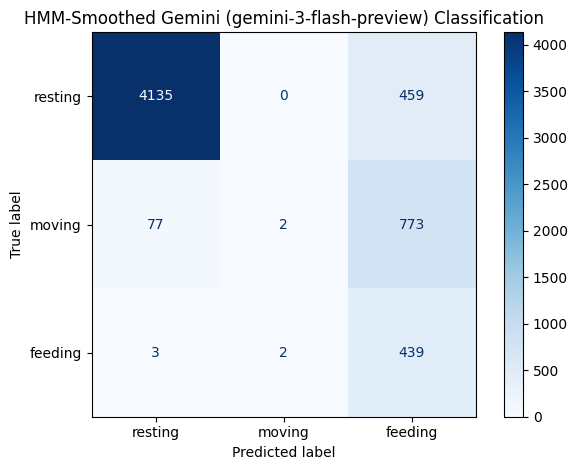

In [ ]:
if 'subset_data' in locals() and 'gemini_pred' in subset_data.columns:
    # 1. Run HMM Smoothing
    A = get_transition_matrix(LABELS_ORDER, DIAG_FLOOR_ALL, DIAG_FLOOR_FEED)
    smoothed_list = []
    for file_name, group in subset_data.groupby('hour_file'):
        obs = group['gemini_pred'].tolist()
        smoothed = viterbi_smoothing(obs, LABELS_ORDER, A)
        smoothed_list.extend(smoothed)

    subset_data['hmm_pred'] = smoothed_list
    print("HMM smoothing complete.\n")

    # 2. Evaluate Results
    labels = LABELS_ORDER
    eval_df = subset_data[subset_data["hmm_pred"] != "unknown"].copy()

    print("Classification Report (HMM Smoothed):")
    print(classification_report(
        eval_df["label"],
        eval_df["hmm_pred"],
        labels=labels,
        target_names=labels
    ))

    cm = confusion_matrix(eval_df["label"], eval_df["hmm_pred"], labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(cmap="Blues")
    plt.title(f"HMM-Smoothed Gemini ({MODEL}) Classification")
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'subset_data' with 'gemini_pred' not found. Please run the Gemini classification cell first.")